# <center> Employee Retention Prediction <center>
![Screenshot%202025-08-28%20125123.png](attachment:Screenshot%202025-08-28%20125123.png)

### Agenda:
1. [Frame the Problem / Business Case](#problem)
2. [Gathering the Data](#data)
3. [Data Pre-Pocessing](#processing)
4. [EDA](#eda)
5. [Feature Engineering](#engg)
6. [Model Training, Evaluation and Selection](#model)

<a id='problem'></a>

## 1. Frame the Problem / Business Case

### Background:
- Hiring and retaining employees are extremely complex tasks that require capital, time and skills
- Small business owners spend **40% of their working** hours on tasks that do **not** generate any income such as hiring
- Companies spend **15%-20%** of the employee's salary to recruit a new candidate
- An average company loses anywhere **between 1% and 2.5%** of their total revenue on the time it takes to bring a new hire up to speed
- It takes **52 days** on average to fill a position

### Problem Statement:
- You work as a data scientist at a Multi-National Corporation
- The HR team collected extensive data on their employees and approached you to develop a model that could predict which employees are more likely to quit
- The team provided you with an extensive dataset, a sample of which is provided:
    - JobInvolvement
    - Education
    - JobSatisfaction
    - PerformanceRating
    - RelationshipSatisfaction
    - WorkLifeBalance

<a id='data'></a>

## 2. Gathering the Data

In [97]:
import pandas as pd
import numpy as np
df=pd.read_csv('Human_Resources.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [98]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset columns:")
print(df.columns.tolist())

Number of rows: 1470
Number of columns: 35

Dataset columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 3. Data Pre-Pocessing

In [99]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [100]:
df.shape

(1470, 35)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [102]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [105]:
df[['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']].nunique()

,0
EmployeeCount,1
EmployeeNumber,1470
Over18,1
StandardHours,1


In [106]:
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)


In [107]:
df.shape

(1470, 31)

In [108]:
df['Attrition'].dtype

dtype('O')

In [109]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


# 4.Feature Engineering

In [110]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})


In [111]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [112]:
df['Attrition'].unique()

array([1, 0])

In [113]:
df.select_dtypes(include='object').nunique()

,0
BusinessTravel,3
Department,3
EducationField,6
Gender,2
JobRole,9
MaritalStatus,3
OverTime,2


In [114]:
df = pd.get_dummies(
    df,
    columns=[
        'BusinessTravel',
        'Department',
        'EducationField',
        'Gender',
        'JobRole',
        'MaritalStatus',
        'OverTime'
    ],
    drop_first=True
)

In [115]:
df.shape

(1470, 45)

In [116]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Res

In [117]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [118]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 44)
y shape: (1470,)


# 5. Model Training, Evaluation and Selection

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [120]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 44)
X_test: (294, 44)
y_train: (1176,)
y_test: (294,)


In [121]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Testing target distribution:
Attrition
0    247
1     47
Name: count, dtype: int64


In [122]:
print("Training percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training percentage:
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64

Testing percentage:
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64


In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [125]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [126]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8605442176870748


In [127]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [128]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[237  10]
 [ 31  16]]


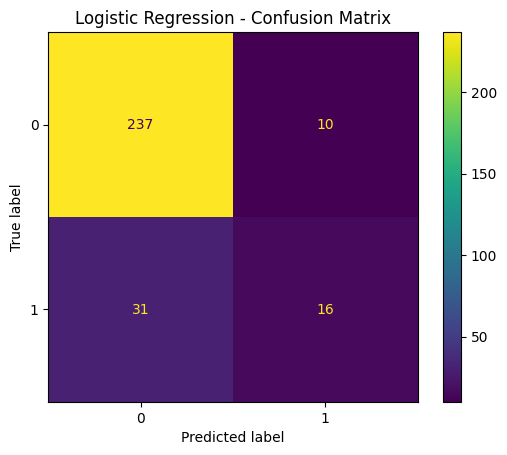

In [129]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [130]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

balanced_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [131]:
y_pred_balanced = balanced_model.predict(X_test_scaled)

In [132]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [133]:
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print(cm_balanced)

[[192  55]
 [ 18  29]]


In [134]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Original Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nBalanced Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1-score :", f1_score(y_test, y_pred_balanced))

Original Logistic Regression
Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1-score : 0.4383561643835616

Balanced Logistic Regression
Accuracy : 0.7517006802721088
Precision: 0.34523809523809523
Recall   : 0.6170212765957447
F1-score : 0.44274809160305345


In [135]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [136]:
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree[:20])

[1 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0]


# **DECISION TREE MODEL**

In [137]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.7653061224489796


In [138]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       247
           1       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294



In [139]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[207  40]
 [ 29  18]]


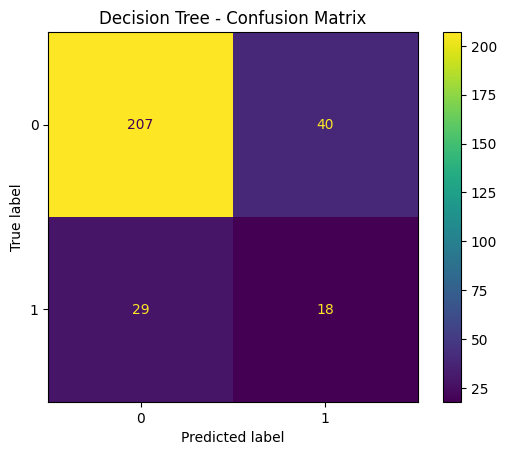

In [140]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=cm_tree).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [141]:
print("Model Comparison")
print("-" * 50)

print("Original Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nBalanced Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1-score :", f1_score(y_test, y_pred_balanced))

print("\nDecision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1-score :", f1_score(y_test, y_pred_tree))

Model Comparison
--------------------------------------------------
Original Logistic Regression
Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1-score : 0.4383561643835616

Balanced Logistic Regression
Accuracy : 0.7517006802721088
Precision: 0.34523809523809523
Recall   : 0.6170212765957447
F1-score : 0.44274809160305345

Decision Tree
Accuracy : 0.7653061224489796
Precision: 0.3103448275862069
Recall   : 0.3829787234042553
F1-score : 0.34285714285714286


In [142]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [143]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


In [144]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8333333333333334


In [145]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [146]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[240   7]
 [ 42   5]]


In [147]:
class_weight='balanced'

In [148]:
balanced_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

balanced_rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [149]:
y_pred_balanced_rf = balanced_rf_model.predict(X_test)

print(y_pred_balanced_rf[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [150]:
accuracy_balanced_rf = accuracy_score(y_test, y_pred_balanced_rf)

print("Balanced Random Forest Accuracy:", accuracy_balanced_rf)

Balanced Random Forest Accuracy: 0.8367346938775511


In [151]:
print(classification_report(y_test, y_pred_balanced_rf))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [152]:
cm_balanced_rf = confusion_matrix(y_test, y_pred_balanced_rf)

print(cm_balanced_rf)

[[242   5]
 [ 43   4]]


In [153]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:20])

[0.07393842 0.00231828 0.10930725 0.00627558 0.32650976 0.27621502
 0.00780165 0.02336146 0.00310943 0.08445156 0.04891148 0.08392238
 0.40995361 0.16736356 0.28575808 0.40894436 0.01630558 0.00531415
 0.26741185 0.01162729]


In [154]:
threshold = 0.30

y_pred_30 = (y_prob >= threshold).astype(int)

print(y_pred_30[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0]


In [155]:
print("Threshold: 0.30")

print("Accuracy :", accuracy_score(y_test, y_pred_30))
print("Precision:", precision_score(y_test, y_pred_30))
print("Recall   :", recall_score(y_test, y_pred_30))
print("F1-score :", f1_score(y_test, y_pred_30))

Threshold: 0.30
Accuracy : 0.8435374149659864
Precision: 0.5106382978723404
Recall   : 0.5106382978723404
F1-score : 0.5106382978723404


In [156]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print("Threshold:", threshold)
    print("Precision:", round(precision_score(y_test, y_pred_threshold), 3))
    print("Recall   :", round(recall_score(y_test, y_pred_threshold), 3))
    print("F1-score :", round(f1_score(y_test, y_pred_threshold), 3))
    print("-" * 30)

Threshold: 0.5
Precision: 0.615
Recall   : 0.34
F1-score : 0.438
------------------------------
Threshold: 0.4
Precision: 0.568
Recall   : 0.447
F1-score : 0.5
------------------------------
Threshold: 0.3
Precision: 0.511
Recall   : 0.511
F1-score : 0.511
------------------------------
Threshold: 0.2
Precision: 0.435
Recall   : 0.638
F1-score : 0.517
------------------------------
Threshold: 0.1
Precision: 0.336
Recall   : 0.809
F1-score : 0.475
------------------------------


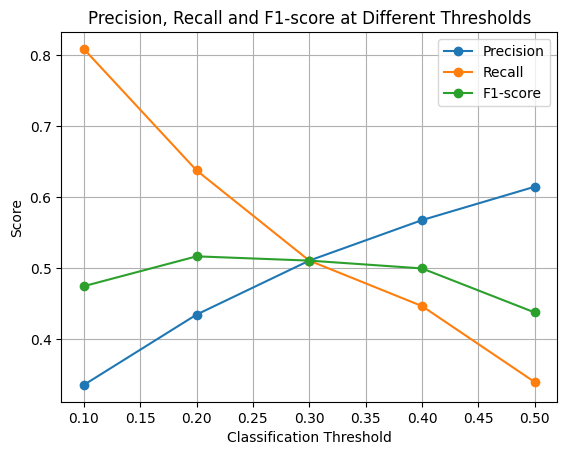

In [157]:
import matplotlib.pyplot as plt

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

precision_values = [0.615, 0.568, 0.511, 0.435, 0.336]
recall_values = [0.340, 0.447, 0.511, 0.638, 0.809]
f1_values = [0.438, 0.500, 0.511, 0.517, 0.475]

plt.plot(thresholds, precision_values, marker='o', label='Precision')
plt.plot(thresholds, recall_values, marker='o', label='Recall')
plt.plot(thresholds, f1_values, marker='o', label='F1-score')

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-score at Different Thresholds")

plt.legend()
plt.grid(True)

plt.show()

In [158]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        0.8605,
        0.7517,
        0.7653,
        0.8333,
        0.8367
    ],
    "Precision (Left)": [
        0.6154,
        0.3452,
        0.3103,
        0.4200,
        0.4400
    ],
    "Recall (Left)": [
        0.3404,
        0.6170,
        0.3830,
        0.1100,
        0.0900
    ],
    "F1-score (Left)": [
        0.4384,
        0.4427,
        0.3430,
        0.1700,
        0.1400
    ]
})

model_comparison

,Model,Accuracy,Precision (Left),Recall (Left),F1-score (Left)
0,Logistic Regression,0.8605,0.6154,0.3404,0.4384
1,Balanced Logistic Regression,0.7517,0.3452,0.6170,0.4427
2,Decision Tree,0.7653,0.3103,0.3830,0.3430
3,Random Forest,0.8333,0.4200,0.1100,0.1700
4,Balanced Random Forest,0.8367,0.4400,0.0900,0.1400


In [159]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8079076578516668


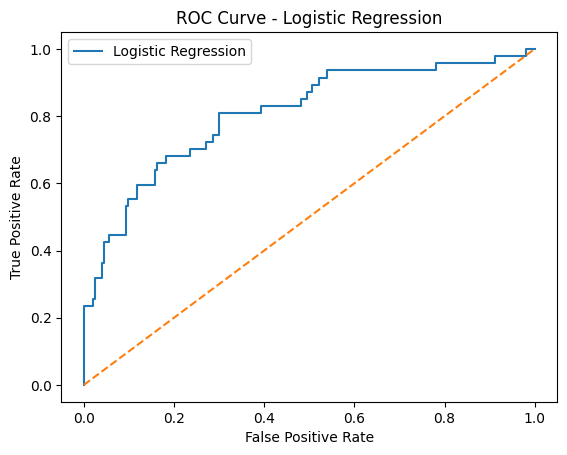

In [160]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

In [161]:
from sklearn.metrics import roc_auc_score

# ROC-AUC for Logistic Regression
auc_lr = roc_auc_score(
    y_test,
    model.predict_proba(X_test_scaled)[:, 1]
)

# ROC-AUC for Balanced Logistic Regression
auc_balanced_lr = roc_auc_score(
    y_test,
    balanced_model.predict_proba(X_test_scaled)[:, 1]
)

# ROC-AUC for Decision Tree
auc_tree = roc_auc_score(
    y_test,
    tree_model.predict_proba(X_test)[:, 1]
)

# ROC-AUC for Random Forest
auc_rf = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
)

# ROC-AUC for Balanced Random Forest
auc_balanced_rf = roc_auc_score(
    y_test,
    balanced_rf_model.predict_proba(X_test)[:, 1]
)

print("Logistic Regression AUC:", auc_lr)
print("Balanced Logistic Regression AUC:", auc_balanced_lr)
print("Decision Tree AUC:", auc_tree)
print("Random Forest AUC:", auc_rf)
print("Balanced Random Forest AUC:", auc_balanced_rf)

Logistic Regression AUC: 0.8079076578516668
Balanced Logistic Regression AUC: 0.7982599707123783
Decision Tree AUC: 0.6105177017830993
Random Forest AUC: 0.7861572917563958
Balanced Random Forest AUC: 0.7514859160995779


In [162]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [0.8605, 0.7517, 0.7653, 0.8333, 0.8367],
    "Precision (Left)": [0.6154, 0.3452, 0.3103, 0.4200, 0.4400],
    "Recall (Left)": [0.3404, 0.6170, 0.3830, 0.1100, 0.0900],
    "F1-score (Left)": [0.4384, 0.4427, 0.3430, 0.1700, 0.1400],
    "ROC-AUC": [
        auc_lr,
        auc_balanced_lr,
        auc_tree,
        auc_rf,
        auc_balanced_rf
    ]
})

final_model_comparison

,Model,Accuracy,Precision (Left),Recall (Left),F1-score (Left),ROC-AUC
0,Logistic Regression,0.8605,0.6154,0.3404,0.4384,0.807908
1,Balanced Logistic Regression,0.7517,0.3452,0.6170,0.4427,0.798260
2,Decision Tree,0.7653,0.3103,0.3830,0.3430,0.610518
3,Random Forest,0.8333,0.4200,0.1100,0.1700,0.786157
4,Balanced Random Forest,0.8367,0.4400,0.0900,0.1400,0.751486


# 6. Exploratory Data Analysis (EDA)

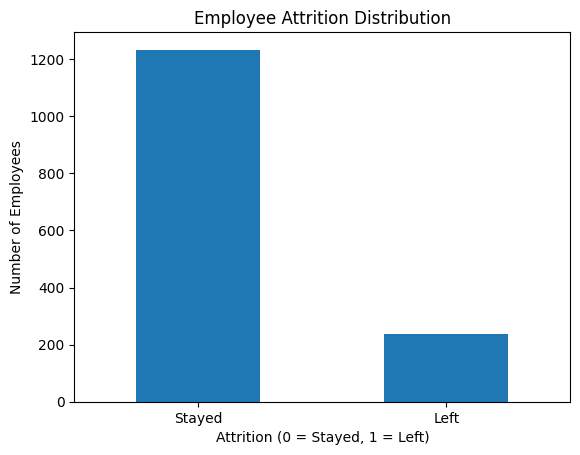

In [163]:
import matplotlib.pyplot as plt

df['Attrition'].value_counts().sort_index().plot(kind='bar')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Employees')
plt.xticks([0, 1], ['Stayed', 'Left'], rotation=0)

plt.show()

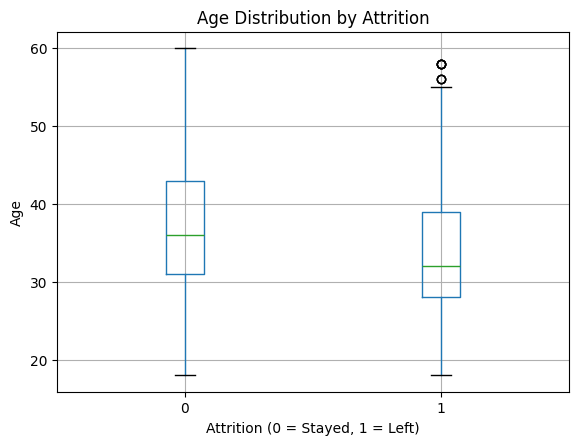

In [164]:
import matplotlib.pyplot as plt

df.boxplot(column='Age', by='Attrition')

plt.title('Age Distribution by Attrition')
plt.suptitle('')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Age')

plt.show()

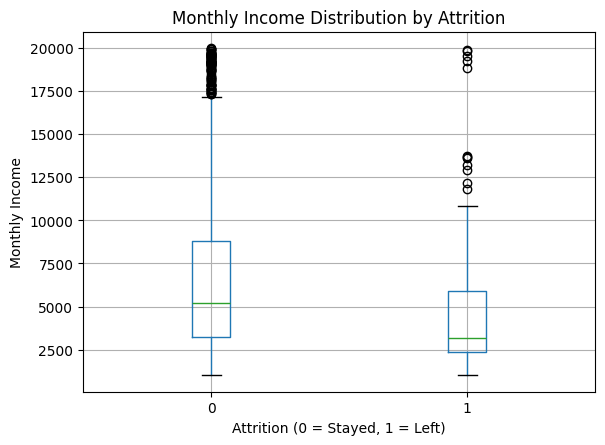

In [165]:
import matplotlib.pyplot as plt

df.boxplot(column='MonthlyIncome', by='Attrition')

plt.title('Monthly Income Distribution by Attrition')
plt.suptitle('')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income')

plt.show()

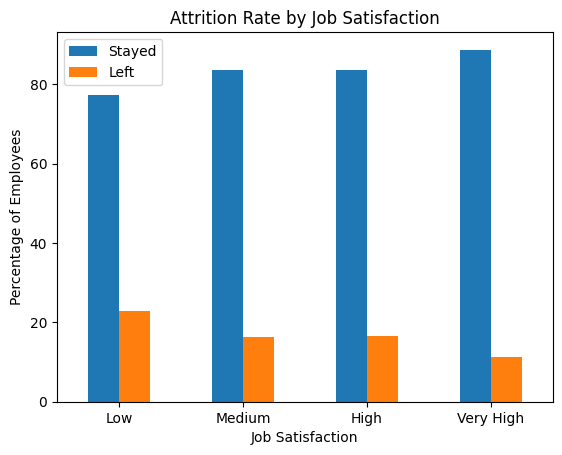

In [166]:
import matplotlib.pyplot as plt

attrition_by_satisfaction = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

attrition_by_satisfaction.plot(kind='bar')

plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Percentage of Employees')
plt.xticks(
    [0, 1, 2, 3],
    ['Low', 'Medium', 'High', 'Very High'],
    rotation=0
)

plt.legend(['Stayed', 'Left'])
plt.show()

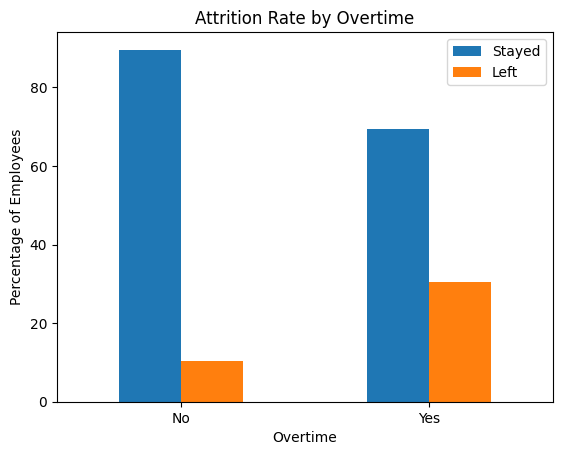

In [167]:
overtime_attrition = pd.crosstab(
    df['OverTime_Yes'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_attrition.plot(kind='bar')

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Percentage of Employees')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

plt.legend(['Stayed', 'Left'])
plt.show()

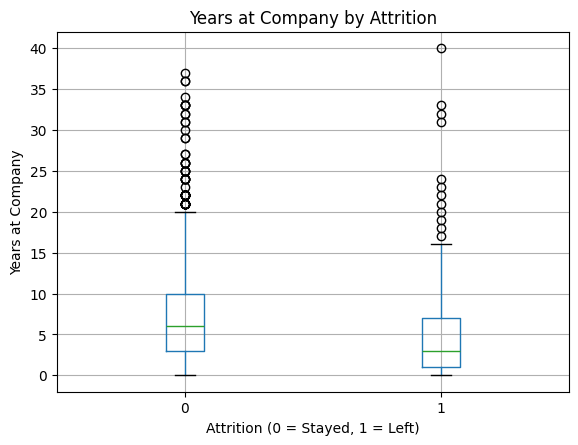

In [168]:
import matplotlib.pyplot as plt

df.boxplot(column='YearsAtCompany', by='Attrition')

plt.title('Years at Company by Attrition')
plt.suptitle('')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Years at Company')

plt.show()

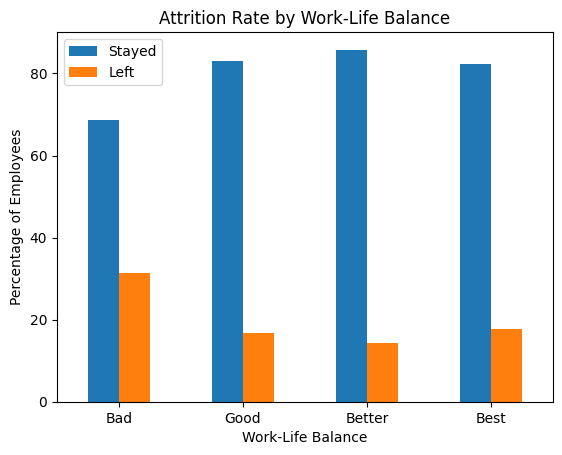

In [169]:
worklife_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

worklife_attrition.plot(kind='bar')

plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Percentage of Employees')
plt.xticks(
    [0, 1, 2, 3],
    ['Bad', 'Good', 'Better', 'Best'],
    rotation=0
)

plt.legend(['Stayed', 'Left'])
plt.show()

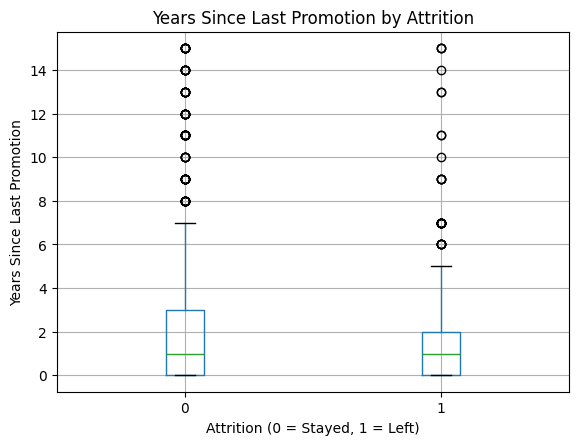

In [170]:
import matplotlib.pyplot as plt

df.boxplot(column='YearsSinceLastPromotion', by='Attrition')

plt.title('Years Since Last Promotion by Attrition')
plt.suptitle('')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Years Since Last Promotion')

plt.show()

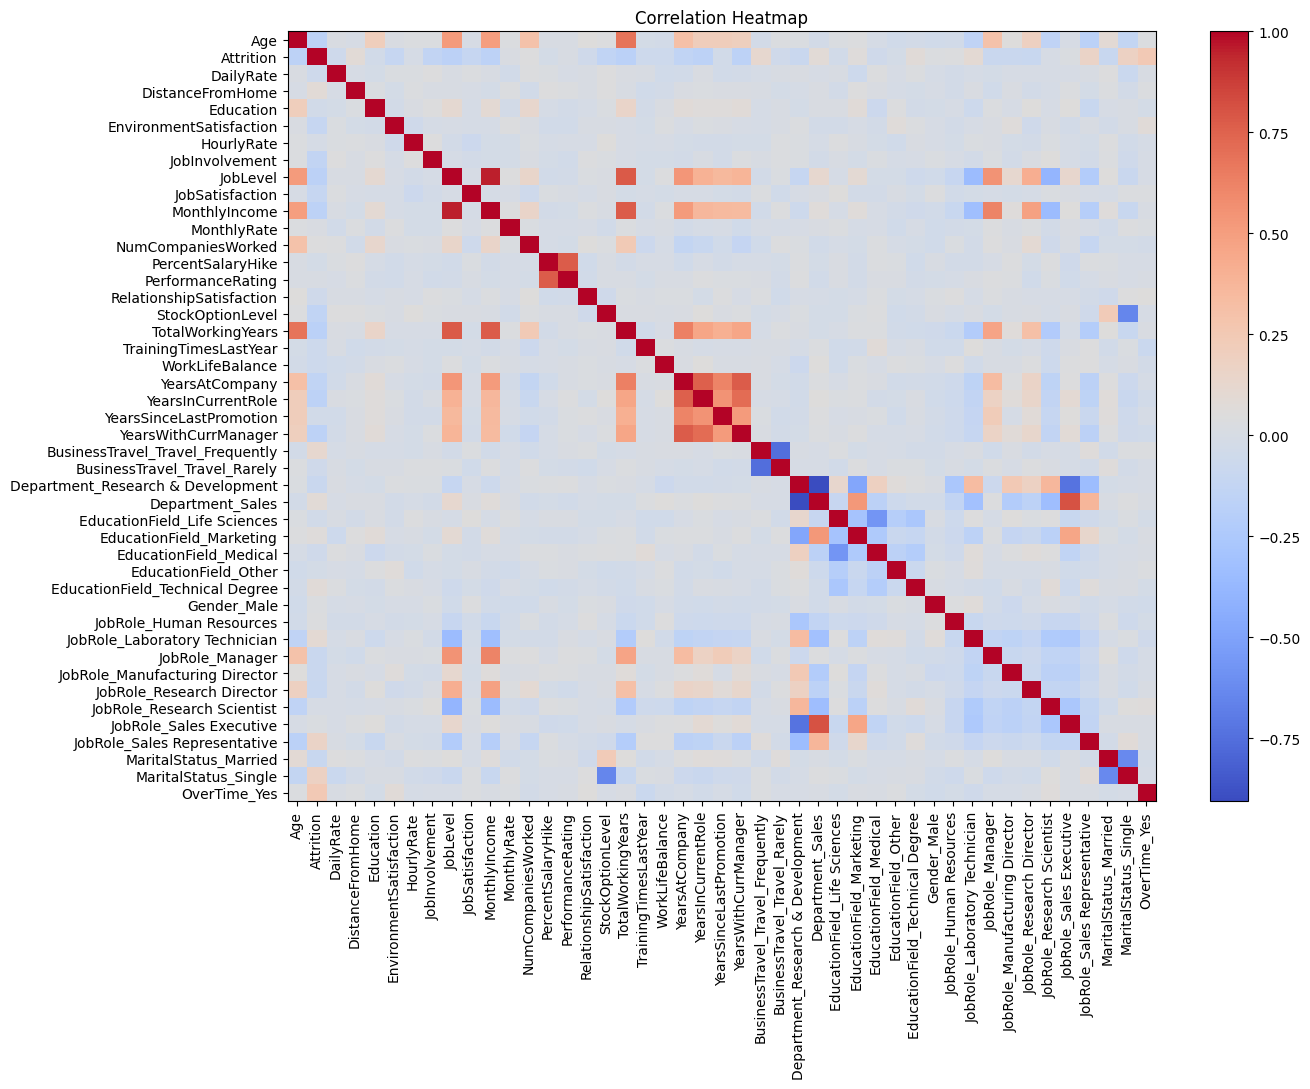

In [171]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.title('Correlation Heatmap')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.show()

In [172]:
attrition_corr = correlation['Attrition'].sort_values(ascending=False)

print(attrition_corr)

Attrition                            1.000000
OverTime_Yes                         0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender_Male                          0.029453
JobRole_Sales Executive              0.019774
MonthlyRate                          0.015170
PerformanceRating                    0.002889
JobRole_Research Scientist          -0.000360
HourlyRate                          -0.006846
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.031373
EducationField_Life Sciences      

In [173]:
overtime_rate = pd.crosstab(
    df['OverTime_Yes'],
    df['Attrition'],
    normalize='index'
) * 100

print(overtime_rate)

Attrition             0          1
OverTime_Yes                      
False         89.563567  10.436433
True          69.471154  30.528846


In [174]:
travel_attrition = pd.crosstab(
    [
        df['BusinessTravel_Travel_Frequently'],
        df['BusinessTravel_Travel_Rarely']
    ],
    df['Attrition'],
    normalize='index'
) * 100

print(travel_attrition)

Attrition                                                              0  \
BusinessTravel_Travel_Frequently BusinessTravel_Travel_Rarely              
False                            False                         92.000000   
                                 True                          85.043145   
True                             False                         75.090253   

Attrition                                                              1  
BusinessTravel_Travel_Frequently BusinessTravel_Travel_Rarely             
False                            False                          8.000000  
                                 True                          14.956855  
True                             False                         24.909747  


In [175]:
marital_attrition = pd.crosstab(
    df['MaritalStatus_Single'],
    df['Attrition'],
    normalize='index'
) * 100

print(marital_attrition)

Attrition                     0          1
MaritalStatus_Single                      
False                 88.300000  11.700000
True                  74.468085  25.531915


In [176]:
job_involvement_attrition = pd.crosstab(
    df['JobInvolvement'],
    df['Attrition'],
    normalize='index'
) * 100

print(job_involvement_attrition)

Attrition               0          1
JobInvolvement                      
1               66.265060  33.734940
2               81.066667  18.933333
3               85.599078  14.400922
4               90.972222   9.027778


In [177]:
joblevel_attrition = pd.crosstab(
    df['JobLevel'],
    df['Attrition'],
    normalize='index'
) * 100

print(joblevel_attrition)

Attrition          0          1
JobLevel                       
1          73.664825  26.335175
2          90.262172   9.737828
3          85.321101  14.678899
4          95.283019   4.716981
5          92.753623   7.246377
